# Task 1.2: 양자 연산 가하기 (Part 2)
## Objective 1b: 고급 & 알고리즘 회로 라이브러리

**Overview:**
이 노트북은 변분 알고리즘과 머신러닝, 최적화에 사용되는 고급 알고리즘 회로를 다룹니다.

- **고급 연산:** 비교 연산, 역수 연산.
- **알고리즘 양자 회로:** 그로버 연산, 위상 측정 등.
- **N-Local 회로:** EfficientSU2, RealAmplitudes (Ansatzes).
- **오라클 & 템플릿:** 그로버 알고리즘 등의 회로를 위한 도구.

In [1]:
# Setup: 사용할 라이브러리를 불러옵니다
from qiskit import ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import quantum_volume
from qiskit.quantum_info import Operator
import numpy as np

print("라이브러리를 성공적으로 불러왔습니다.")

라이브러리를 성공적으로 불러왔습니다.


### 고급 연산

#### **고급 연산 블럭: 기타 연산 함수**

Qiskit의 회로 라이브러리에는 다양한 특화 연산 컴포넌트가 있습니다. 이 게이트와 회로들은 양자 회로를 만드는데에 효과적으로 활용될 수 있습니다. 이 함수들은 두 가지 형태로 존재합니다: 연산이 수학적으로 정의된 `Gate`의 형태로 트랜스파일러를 통해 최적화할 수 있는 형태, 그리고 `QuantumCircuit`으로 구현되어 알고리즘을 곧바로 불러올 수 있는 형태입니다.

**Gate 형태**

- **ExactReciprocalGate**:	정확한 역수 함수 `f(x) = 1/x`을 구현합니다.
- **IntegerComparatorGate**:	큐비트 상에서 정수의 `≥` 또는 `<` 연산을 구현합니다.
- **QuadraticFormGate**:	큐비트 상에서 이진 변수의 이차함수를 구현합니다.
- **WeightedSumGate**:	큐비트 상에서 각 변수에 가중치가 곱해진 가중합 `Σ(wᵢ -**xᵢ)`을 계산합니다.

**QuantumCircuit 형태** 

- **ExactReciprocal**:	Exact reciprocal의 `QuantumCircuit` 형태입니다.
- **IntegerComparator**:	Integer comparator의 `QuantumCircuit` 형태입니다.
- **QuadraticForm**:	Quadratic form의 `QuantumCircuit` 형태입니다.
- **WeightedAdder**:	Weighted sum의 `QuantumCircuit` 형태입니다.

Integer Comparator Circuit:


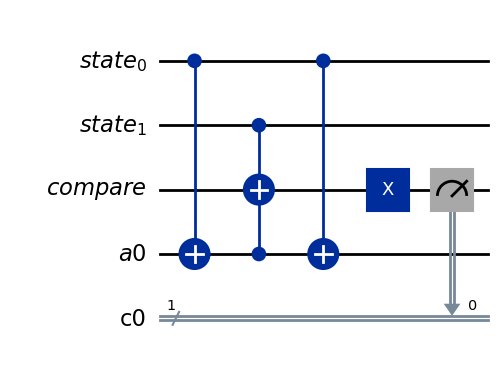

In [2]:
from qiskit.circuit.library import IntegerComparator

# Example 1: Integer Comparator as a Gate
# Compare if a 2-qubit number (0-3) is < 3 
qc = IntegerComparator(2, 3, geq=False)
qc.add_register(ClassicalRegister(1))
#Result is stored in the third qubit (flips if condition is true)
#Output is 0 < 3  => True , third qubit should be flipped
qc.measure(2,0)
print("Integer Comparator Circuit:")
qc.decompose().draw('mpl')

Weighted Adder Circuit:


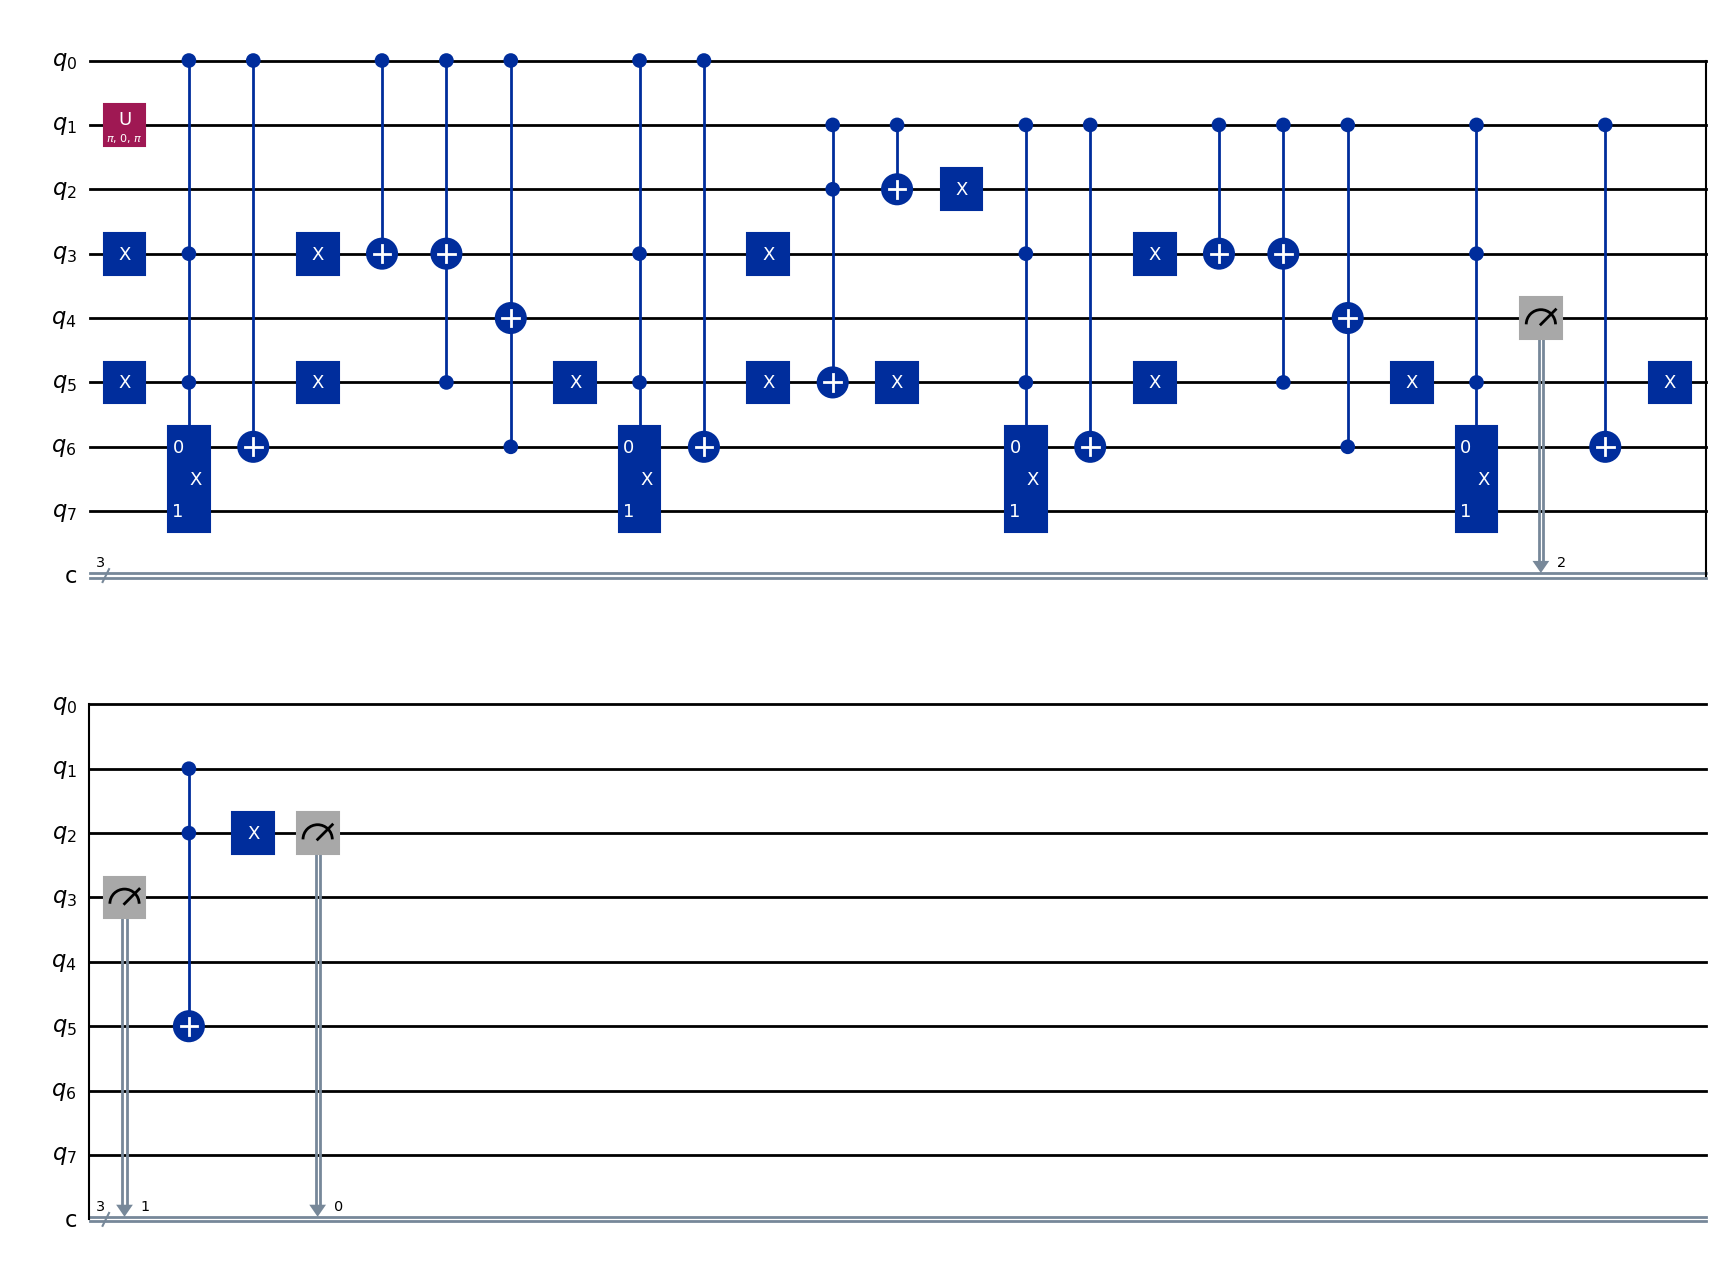

In [4]:
from qiskit.circuit.library import WeightedAdder

# Example 2: Weighted Adder as a Circuit
# Compute weighted sum: 2*x0 + 3*x1
weights = [2, 3]


weighted_adder = WeightedAdder(2, weights=weights)
qc = QuantumCircuit(weighted_adder.num_qubits, 3)
# setup input to represent x1=1 (qubit 1) and x0=0 (qubit 0)
qc.x(1)
# append the weighted adder circuit
qc.append(weighted_adder, range(weighted_adder.num_qubits))
#Output is stored in 3-qubit sum register in qubits 2,3,4
#Output is 3*1 + 2*0 = 3
qc.measure(range(2, 5), range(3))
print("Weighted Adder Circuit:")
qc.decompose(reps=2).draw('mpl')

Measurement Output: {'011': 1000}


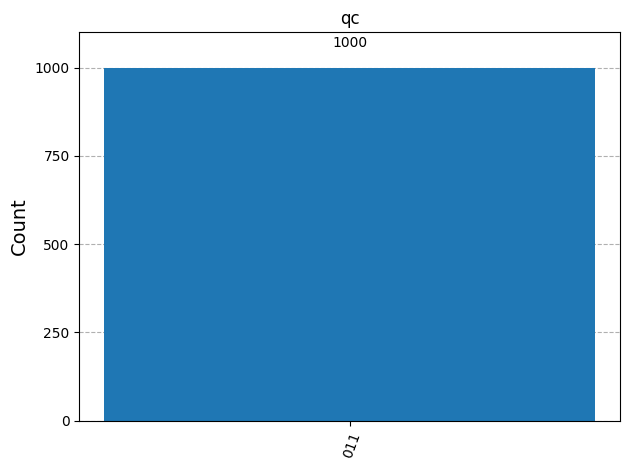

In [5]:
sim_ideal = AerSimulator()
result = sim_ideal.run(transpile(qc , sim_ideal),shots=1000).result()
counts = result.get_counts(0)
print("Measurement Output:", counts)
plot_histogram(counts, title='qc')


### 알고리즘 양자 회로

특정한 양자 알고리즘이나 어플리케이션에 사용되는 회로입니다. 이 함수들 또한 `Gate`와 `QuantumCircuit` 형태로 존재합니다.


- **fourier_checking** :	Fourier checking 알고리즘의 회로입니다.
- **hidden_linear_function** :	Hidden linear function 문제를 푸는 회로입니다.
- **iqp** :	Instantaneous quantum polynomial time (IQP) 회로입니다.
- **random_iqp** :	Random instantaneous quantum polynomial time (IQP) 회로입니다.
- **quantum_volume** :	Quantum volume을 측정하는데 사용되는 회로입니다.
- **phase_estimation** :	유니터리 연산자 U의 고윳값 $e^{2\pi i\phi}$로 나타나는 위상 `ϕ`를 측정하는 위상 측정 회로입니다.
- **grover_operator** :	그로버 탐색 알고리즘에서 사용되는 그로버 연산 회로입니다.
- **unitary_overlap** :	두 개의 유니터리 연산자 사이의 overlap U2†U1을 계산하는 회로입니다.
- **GraphStateGate** :	Graph state를 구현하는 회로입니다.
- **PauliEvolutionGate** :	파울리 연산자로 구성된 연산자의 time-evolution을 구현하는 회로입니다.
- **HamiltonianGate** :	해밀토니안 연산자의 evolution을 구현하는 게이트를 나타내는 클래스입니다.

**QuantumCircuit 형태**

- **FourierChecking** :	Fourier checking의 `QuantumCircuit` 형태입니다.
- **GraphState** :	Graph state의 `QuantumCircuit` 형태입니다.
- **HiddenLinearFunction** :	Hidden Linear function의 `QuantumCircuit` 형태입니다.
- **IQP** :	Instantaneous quantum polynomial (IQP)의 `QuantumCircuit` 형태입니다.
- **QuantumVolume** :	Quantum volume model의 `QuantumCircuit` 형태입니다.
- **PhaseEstimation** :	Phase Estimation의 `QuantumCircuit` 형태입니다.
- **GroverOperator** :	Grover operator의 `QuantumCircuit` 형태입니다.
- **UnitaryOverlap** :	Unitary overlap의 `QuantumCircuit` 형태입니다.

Quantum Volume Circuit:


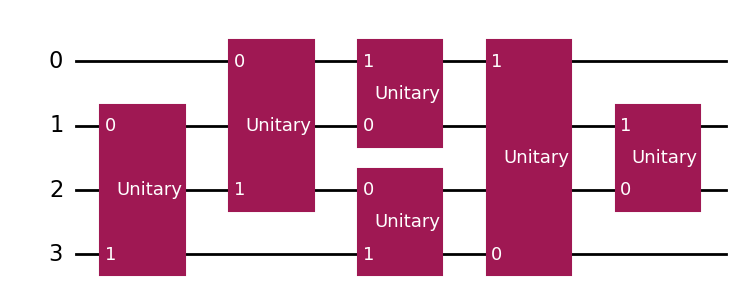

In [5]:
# Example 1: Quantum Volume Circuit 
qc = quantum_volume(4, depth=3)
print("Quantum Volume Circuit:")
qc.draw('mpl')

C:\Users\BoseongKim\AppData\Local\Temp\ipykernel_36824\2951843498.py:13: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  phase_est = PhaseEstimation(num_eval_qubits, unitary)


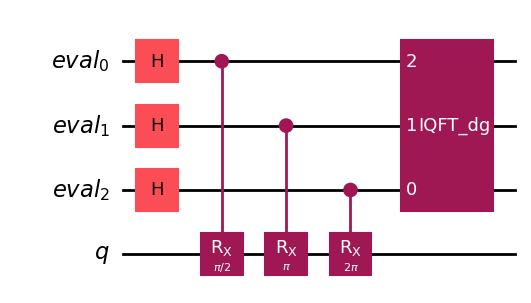

In [6]:
from qiskit.circuit.library import PhaseEstimation
from qiskit.circuit.library import RXGate

# Example 2: Phase Estimation as a Circuit
# Estimate the phase of a unitary operator

# Number of evaluation qubits
num_eval_qubits = 3

# Simple unitary - S gate with known phase
unitary = RXGate(np.pi/2)

phase_est = PhaseEstimation(num_eval_qubits, unitary)
phase_est.decompose().draw('mpl')

### N-Local 회로 

N Local 회로는 VQE나 QAOA와 같은 변분 양자 알고리즘에서 ansatz로 자주 쓰이는 매개변수화된 양자 회로입니다. 이 함수들은 `BlueprintCircuit` 형태와 `QuantumCircuit` 형태로 존재합니다. BlueprintCircuit은 회로를 블록화하여 자체적인 변형 또는 최적화가 가능한 형태이고, QuantumCircuit은 회로를 빠르게 구현하는데에 유용합니다.



**`QuantumCircuit` 형태**

- **n_local**:	회전 레이어와 얽힘 레이어가 교차로 가해지는 n-local 변분 회로를 구현합니다.
- **efficient_su2**:	변분 알고리즘과 classification에 주로 사용되는 하드웨어-맞춤 SU(2) 2-local 회로를 구현합니다.
- **real_amplitudes**:	화학, 최적화, 머신러닝 어플리케이션에 주로 사용되는 real-amplitudes 2-local 회로를 구현합니다.
- **pauli_two_design**:	Pauli 2-design ansatz를 구현합니다.
- **excitation_preserving**:	휴리스틱 excitation-preserving 파동함수 ansatz를 구현합니다.
- **qaoa_ansatz**:	초기 상태와 믹서를 커스텀할 수 있는 일반화된 QAOA 양자 회로를 구현합니다.
- **hamiltonian_variational_ansatz**:	Hamiltonian의 변분 ansatz를 구현합니다.
- **evolved_operator_ansatz**:	연산자의 evolution 형태로 나타나는 ansatz를 구현합니다.

**`BlueprintCircuit` 형태** 

- **NLocal**:	n-local의 `BlueprintCircuit` 형태입니다.
- **TwoLocal**:	two-local의 `BlueprintCircuit` 형태입니다.
- **PauliTwoDesign**: Pauli Two-Design ansatz의 `BlueprintCircuit` 형태입니다.
- **RealAmplitudes**: real-amplitudes 2-local의 `BlueprintCircuit` 형태입니다.
- **EfficientSU2**:	Hardware efficient SU(2) 2-local의 `BlueprintCircuit` 형태입니다.
- **EvolvedOperatorAnsatz**:	The evolved operator ansatz의 `BlueprintCircuit` 형태입니다.
- **ExcitationPreserving**:	Excitation-preserving ansatz의 `BlueprintCircuit` 형태입니다.
- **QAOAAnsatz**:	QAOA의 `BlueprintCircuit` 형태입니다.


RealAmplitudes Ansatz (3 qubits, pairwise entanglement):

Number of parameters: 9
Parameter names: ['θ[0]', 'θ[1]', 'θ[2]', 'θ[3]', 'θ[4]', 'θ[5]', 'θ[6]', 'θ[7]', 'θ[8]']


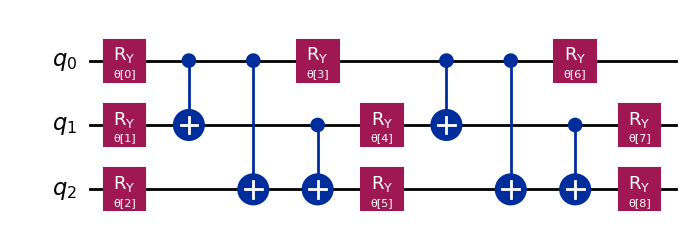

In [7]:
from qiskit.circuit.library import real_amplitudes, EfficientSU2

# Example 1: real_amplitudes ansatz
# Commonly used for quantum chemistry problems
ansatz = real_amplitudes(3, entanglement="full", reps=2)
print("\nRealAmplitudes Ansatz (3 qubits, pairwise entanglement):")
# Show the parameters
print(f"\nNumber of parameters: {ansatz.num_parameters}")
print(f"Parameter names: {[p.name for p in ansatz.parameters]}")
ansatz.draw('mpl')



C:\Users\karim\AppData\Local\Temp\ipykernel_20396\4265856534.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  efficient_ansatz = EfficientSU2(3, entanglement="full", reps=2)



EfficientSU2 Ansatz (3 qubits, full entanglement):


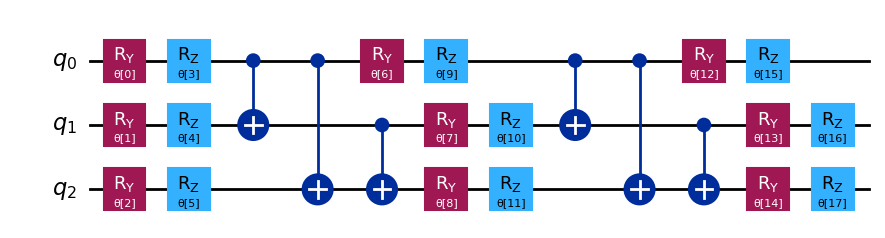

In [8]:
# Example 2: EfficientSU2 ansatz as BlueprintCircuit
# Hardware-efficient ansatz with SU(2) rotations
# use full entanglement and 2 repetitions
efficient_ansatz = EfficientSU2(3, entanglement="full", reps=2)
print("\nEfficientSU2 Ansatz (3 qubits, full entanglement):")
efficient_ansatz.decompose().draw('mpl')

### 데이터 인코딩 회로



데이터 인코딩 회로는 양자 머신러닝에서 고전적인 데이터를 양자 상태로 인코딩하는데에 사용됩니다. 이 함수들도 `BlueprintCircuit` 형태와 `QuantumCircuit` 형태로 존재합니다.

**`QuantumCircuit` 형태** 

- **pauli_feature_map**: 파울리 게이트를 사용해 데이터를 인코딩하는 파울리 전개 회로입니다.
- **z_feature_map**: 일차 파울리-Z evolution 회로입니다. `pauli_feature_map`에서 'Z' 게이트만을 사용하는 것과 같습니다.
- **zz_feature_map**: 이차 파울리-Z evolution 회로입니다.

**`BlueprintCircuit` 형태** 

- **PauliFeatureMap**:	파울리 전개의 `BlueprintCircuit` 형태입니다.
- **ZFeatureMap**:	일차 파울리-Z evolution의 `BlueprintCircuit` 형태입니다.
- **ZZFeatureMap**:	이차 파울리-Z evolution의 `BlueprintCircuit` 형태입니다.



ZFeatureMap (3 qubits, 2 repetitions):


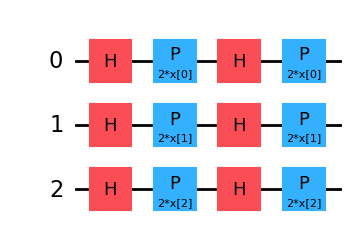

In [9]:
from qiskit.circuit.library import z_feature_map

# Example 1: PauliFeatureMap as BlueprintCircuit
z_map = z_feature_map(3, reps=2)
print("\nZFeatureMap (3 qubits, 2 repetitions):")
z_map.draw('mpl')

C:\Users\karim\AppData\Local\Temp\ipykernel_20396\865897456.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation.pauli_feature_map.PauliFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the pauli_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  p_map = PauliFeatureMap(3, reps=2, paulis=['ZZ', 'XX'])



PauliFeatureMap (3 qubits, 2 repetitions):


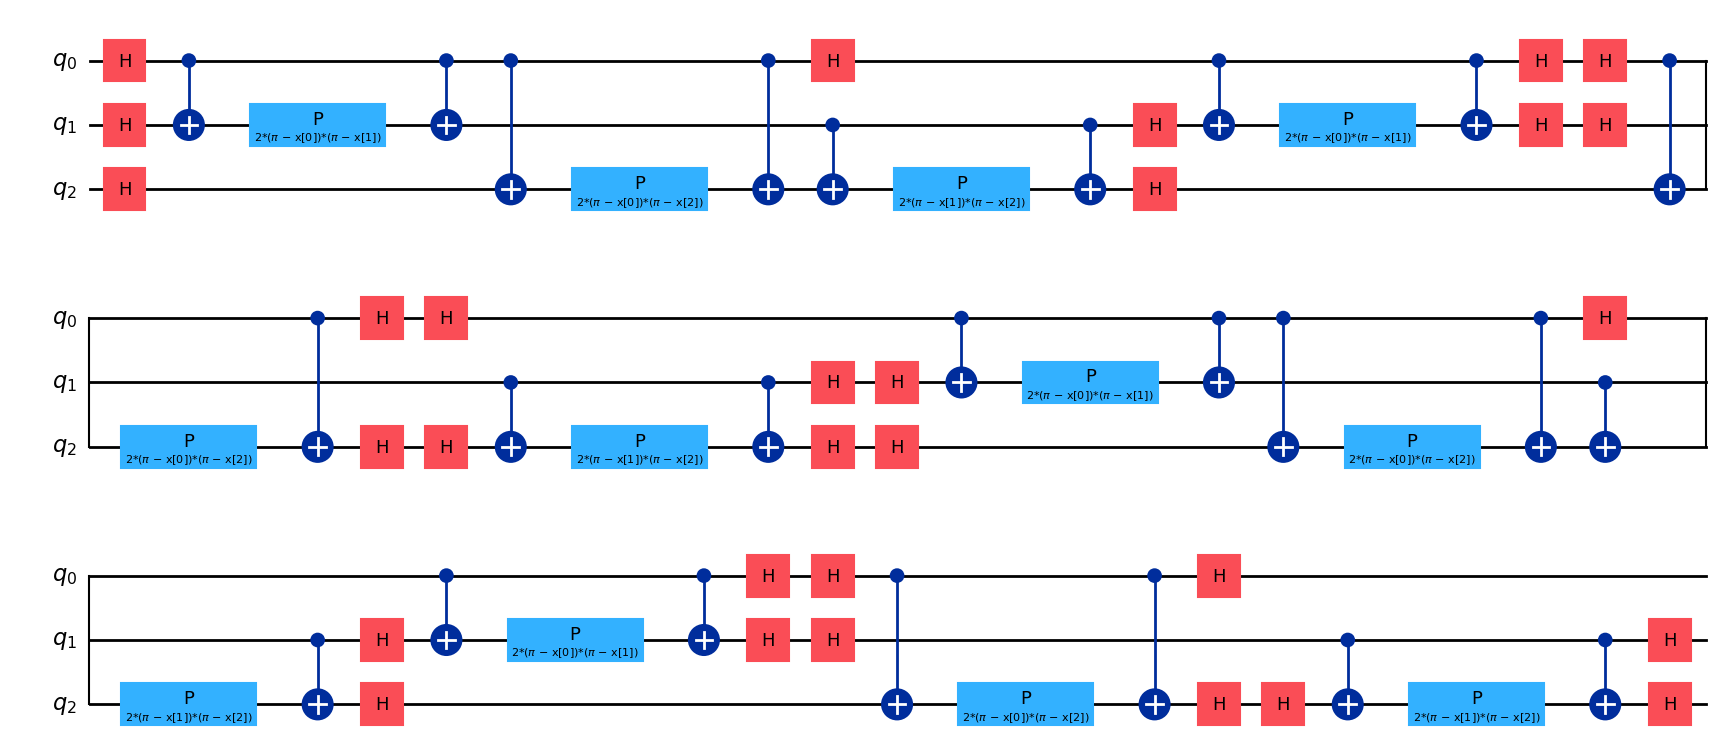

In [10]:
from qiskit.circuit.library import PauliFeatureMap

# Example 1: PauliFeatureMap as BlueprintCircuit
p_map = PauliFeatureMap(3, reps=2, paulis=['ZZ', 'XX'])
print("\nPauliFeatureMap (3 qubits, 2 repetitions):")
p_map.decompose().draw('mpl')

### 데이터 준비 회로

- **StatePrepration** : 복잡한 양자 상태의 준비에 활용할 수 있습니다.
- **Initialize**: 복잡한 양자 상태로 초기화하는 데에 활용할 수 있습니다. 여기에는 reset 연산이 포함되기 때문에 `Gate`가 아닌 `Insturction`으로 분류됩니다.


State Preparation Circuit for |ψ⟩ = (|00⟩ + |11⟩)/√2:


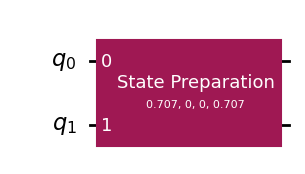

In [11]:
# Example: State Preparation Circuit
from qiskit.circuit.library import StatePreparation

# Prepare a specific 3-qubit state |ψ⟩ = (|00⟩ + |11⟩)/√2
# Define the target state amplitudes 00, 01, 10, 11
target_state = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)]
state_prep = StatePreparation(target_state)
print("\nState Preparation Circuit for |ψ⟩ = (|00⟩ + |11⟩)/√2:")
# use in circuit
qc = QuantumCircuit(state_prep.num_qubits)
qc.append(state_prep, range(state_prep.num_qubits))
qc.draw('mpl')


### 오라클

양자 블랙박스 연산입니다.

**`Gate` 형태**

- **PhaseOracleGate**: 위상 오라클을 구현합니다.
- **BitFlipOracleGate**: 비트 반전 오라클을 구현합니다.

**`QuantumCircuit` 형태**

- **PhaseOracle**: 위상 오라클의 `QuantumCircuit` 형태입니다.


Bit Flip Oracle for expression: (a | b | c)


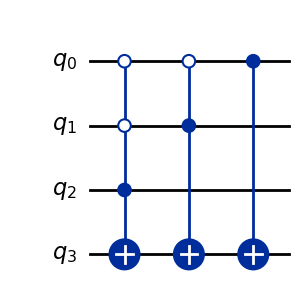

In [12]:
from qiskit.circuit.library import BitFlipOracleGate

# Example 1: BitFlip Oracle Gate
# Create an oracle that marks solutions to (a | b | c)

logical_expr = "(a | b | c)"
oracle = BitFlipOracleGate(logical_expr)
qc=QuantumCircuit(oracle.num_qubits)
qc.append(oracle, range(oracle.num_qubits))
print("\nBit Flip Oracle for expression:", logical_expr)
qc.decompose().draw('mpl')


Phase Oracle for expression: (a & b) | (c & d)


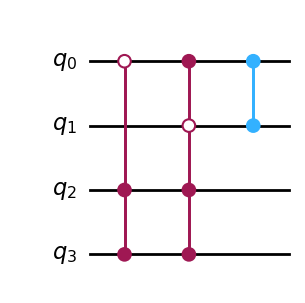

In [13]:
from qiskit.circuit.library import PhaseOracleGate

# Example 2: Phase Oracle for logical expressions
# Create an oracle that marks solutions to (a AND b) OR (c AND d)

logical_expr = "(a & b) | (c & d)"
oracle = PhaseOracleGate(logical_expr)
qc=QuantumCircuit(oracle.num_qubits)
qc.append(oracle, range(oracle.num_qubits))
print("\nPhase Oracle for expression:", logical_expr)
qc.decompose().draw('mpl')

### 템플릿 회로

템플릿 회로는 항등 연산을 수행하는 회로입니다. 이들은 회로의 최적화에 이용할 수 있습니다.

- **NCT (Not-CNot-toffoli)** : `XGate`, `CXGate`, `CCXGate`만을 사용하는 템플릿 회로입니다.
- **Clifford** : 클리포드 게이트만을 사용하는 템플릿 회로입니다.
- **RZX** : `RZXGate`를 사용하는 템플릿 회로입니다.


Template Verification:
template_nct_4b_1 is identity: True

Template Circuit (template_nct_4b_1):


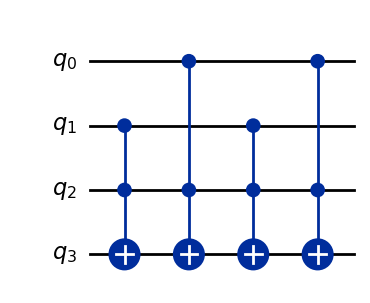

In [14]:
from qiskit.circuit.library.templates import template_nct_4b_1

# Example 1: template_nct_4b_1 verification
template = template_nct_4b_1()
identity = np.identity(2 ** len(template.qubits), dtype=complex)
data = Operator(template).data
is_identity = np.allclose(data, identity)

print("\nTemplate Verification:")
print(f"template_nct_4b_1 is identity: {is_identity}")

print("\nTemplate Circuit (template_nct_4b_1):")
template.draw('mpl')

---
## 요약
---

이 노트북에서는 다음의 내용을 다루었습니다:

## 고급 & 연산 회로 라이브러리:

1. **고급 연산 회로:** 비교 연산, 역수 연산, 가중합 회로 등.
2. **특정 양자 회로:** 그로버 연산, 위상 측정 등.
3. **N-Local 회로:** EfficientSU2, RealAmplitudes (Ansatzes).
4. **오라클:** 위상 반전, 비트 반전 등.
5. **템플릿:** 회로 최적화에 사용할 수 있는 항등 연산을 수행하는 회로.

---

## 연습 문제

**1. Which of these circuits would you use to compute the weighted sum 2*x₀ + 3*x₁ where x₀ and x₁ are binary inputs encoded in qubits?**

```python
from qiskit.circuit.library import ______
weights = [2, 3]
circuit = ______(2, weights=weights)
```

What should fill in the blanks?

A) WeightedSumGate and WeightedSum

B) WeightedSumGate and WeightedAdder

C) WeightedSum and WeightedSumCircuit

D) IntegerAdder and WeightedAdder


***정답:***
<Details>
<br/>
B) WeightedSumGate와 WeightedAdder회로가 큐비트의 가중합을 계산하는 데에 사용되는 방법입니다.
</Details>

----

**2) What does the following code demonstrate about template circuits?**

```python
from qiskit.circuit.library.templates import template_nct_4b_1
from qiskit.quantum_info import Operator
import numpy as np

template = template_nct_4b_1()
identity = np.identity(2 ** len(template.qubits), dtype=complex)
data = Operator(template).data
is_identity = np.allclose(data, identity)
print(f"Template is identity: {is_identity}")
```

A) Templates are optimized versions of common circuits

B) Templates are error correction circuits

C) Templates are parameterized circuits for variational algorithms

D) Templates compute the identity operation and are used for circuit optimization


***정답:***
<Details>
<br/>
D) 탬플릿은 항등 연산을 수행하는 회로이며, 회로의 최적화에 사용됩니다.
</Details>

----